In [1]:
import clip
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm

from ca_sae.sae.batch_top_k import BatchTopKSAE
from ca_sae.sae.softsae import SoftSAE
from ca_sae.sae.ca_sae import ClassAlignedSAE

In [2]:
clip_model, clip_preprocess = clip.load("ViT-B/32")

In [3]:
def transform(batch):
    batch["pixel_values"] = [
        clip_preprocess(image.convert("RGB"))
        for image in batch["image"]
    ]
    del batch['image']
    return batch



imagenet100 = load_dataset(
    "clane9/imagenet-100", cache_dir="../hf_cache", split="validation"
)
imagenet100.set_transform(transform)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [4]:
dataloader = DataLoader(imagenet100, batch_size=64)

In [5]:
# sae = SoftSAE.from_pretrained("../checkpoints/test/rework_v1_basic_l0/ae.pt").cuda()
# sae = SoftSAE.from_pretrained("../checkpoints/test/SoftSAE_4096_64/ae.pt").cuda()
# sae = SoftSAE.from_pretrained("../checkpoints/test/rework_v1_gradient_trick/ae.pt").cuda()
# sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v1/ae.pt", features_per_class=5).cuda()
sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v2").cuda()
# sae = BatchTopKSAE.from_pretrained("../checkpoints/test/BatchTopKSAESecond/ae.pt").cuda()
sae = sae.eval()

In [6]:
clip_embeddings= []
sae_embeddings = []
labels = []

with torch.inference_mode():
    for batch in tqdm(dataloader):
        images = batch['pixel_values'].cuda()
        labels_batch = batch['label']

        clip_out = clip_model.encode_image(images)
        sae_out = sae.encode(clip_out)

        clip_embeddings.append(clip_out)
        sae_embeddings.append(sae_out)
        labels.append(labels_batch)
        

100%|██████████| 79/79 [00:10<00:00,  7.49it/s]


In [7]:
clip_embeddings = torch.cat(clip_embeddings)
sae_embeddings = torch.cat(sae_embeddings)
labels = torch.cat(labels)

# K Distribution

(array([1.84782593e-03, 9.72826006e-03, 2.10869548e-02, 2.16847808e-02,
        2.78804325e-02, 2.08695635e-02, 1.29347815e-02, 1.27173902e-02,
        1.14674022e-02, 6.90217334e-03, 9.83695571e-03, 7.71739066e-03,
        6.14131020e-03, 7.17389758e-03, 8.26088601e-03, 4.99998922e-03,
        6.25001244e-03, 5.59782562e-03, 5.16304305e-03, 6.57608641e-03,
        6.95652116e-03, 4.29347790e-03, 5.59782562e-03, 5.97826037e-03,
        4.18478226e-03, 4.94565176e-03, 4.07608662e-03, 3.69565187e-03,
        2.98913019e-03, 3.47826779e-03, 2.71738545e-03, 1.03260647e-03,
        1.84782976e-03, 1.63043803e-03, 5.97824798e-04, 7.60871080e-04,
        5.43477089e-04, 3.80435540e-04, 2.71738545e-04, 1.63043803e-04,
        1.63043127e-04, 2.17391737e-04, 1.63043127e-04, 5.43479343e-05,
        0.00000000e+00, 5.43479343e-05, 0.00000000e+00, 0.00000000e+00,
        5.43477089e-05, 5.43479343e-05]),
 array([ 18.        ,  21.68000031,  25.36000061,  29.04000092,
         32.72000122,  36.4000

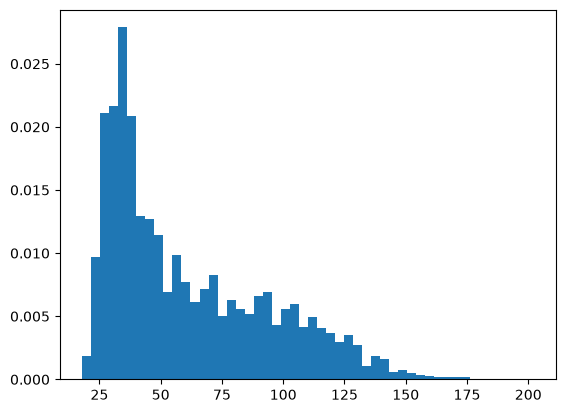

In [8]:
ks = (sae_embeddings !=  0).float().sum(dim=-1).cpu().numpy()

plt.hist(ks, bins=50, density=True)

# Feature examinationn

In [9]:
print("Dead features:",   torch.all(sae_embeddings == 0, dim=0).sum().item())

Dead features: 96


In [10]:
preview_ds = load_dataset(
    "clane9/imagenet-100", cache_dir="../hf_cache", split="validation"
)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [17]:
row, col = torch.unravel_index(sae_embeddings.argmax(), sae_embeddings.shape)

examples_ = sae_embeddings[:, col].topk(10)
examples  = examples_.indices[examples_.values.nonzero()]
examples
col

tensor(227, device='cuda:0')

In [12]:
sae_embeddings.mean(dim=0).topk(10).indices

tensor([ 227,  344,  373, 1067,  723,  836, 2755,   36, 3607, 1304],
       device='cuda:0')

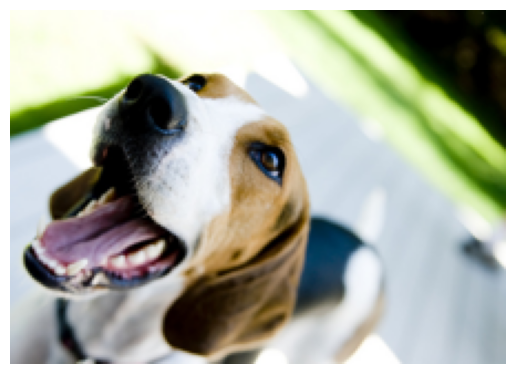

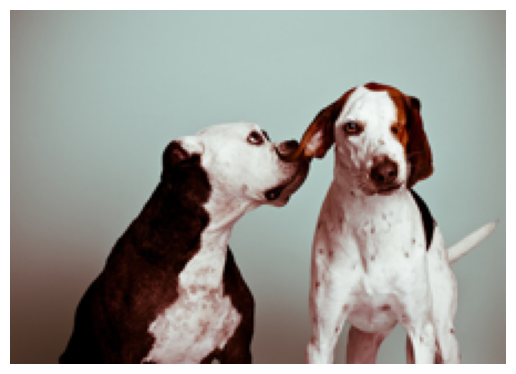

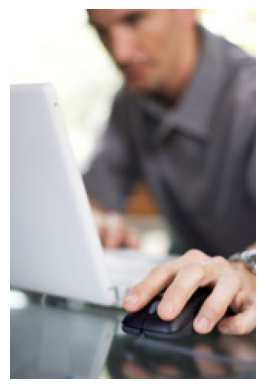

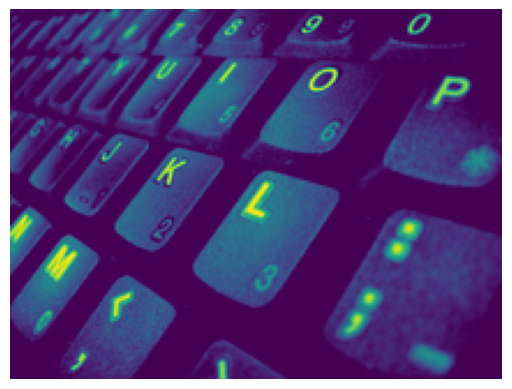

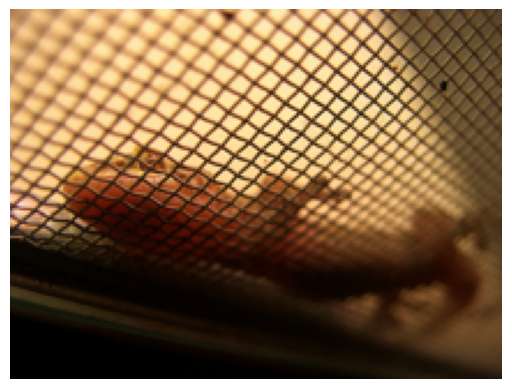

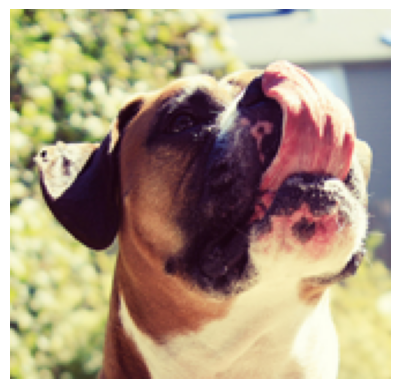

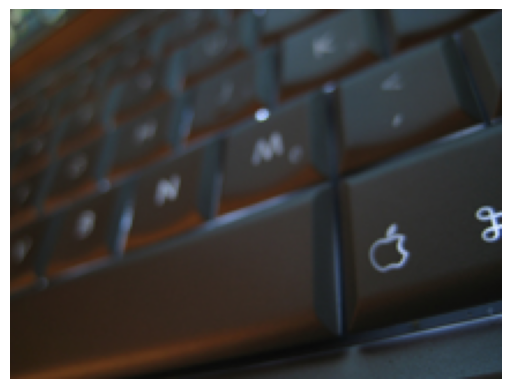

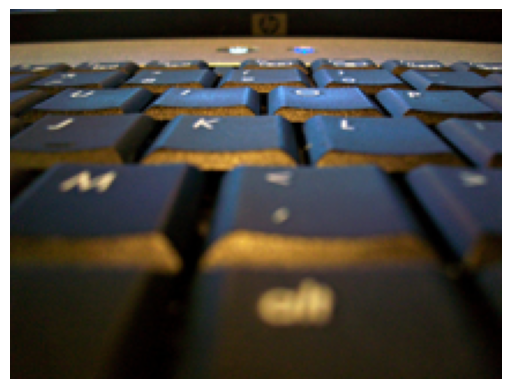

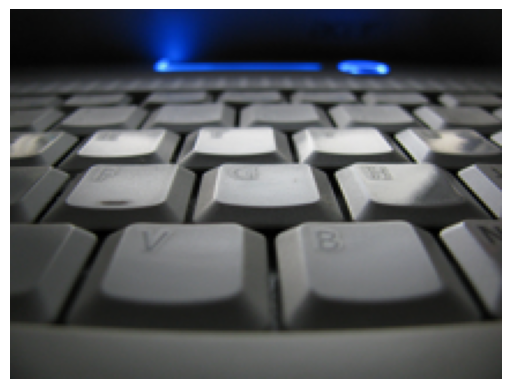

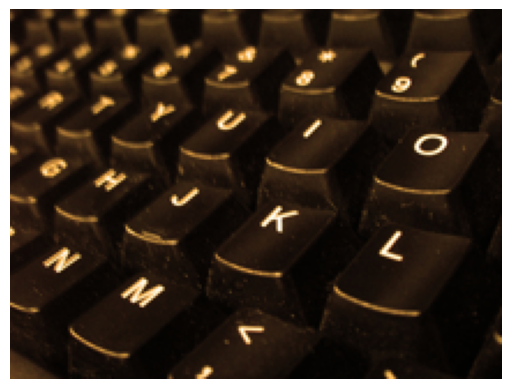

In [13]:
for e in examples:
    plt.axis('off')
    plt.imshow(preview_ds[e.item()]['image'])
    plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(clip_embeddings.clone().cpu().numpy(), labels.clone().cpu().numpy())

probe = LogisticRegression(max_iter=1000)

probe.fit(X_train, y_train)

y_pred = probe.predict(X_test)
accuracy_score(y_test, y_pred)

0.8776

In [15]:
X_train, X_test, y_train, y_test = train_test_split(sae_embeddings.clone().cpu().numpy(), labels.clone().cpu().numpy())

probe = LogisticRegression(max_iter=1000)

probe.fit(X_train, y_train)

y_pred = probe.predict(X_test)
accuracy_score(y_test, y_pred)

0.8704